In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df=pd.read_csv('../data.csv')

In [30]:
df

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175772,1.0,2015-02-17 00:19:41,2015-02-17 01:02:41,28,4.0,3,1389,3,345,649,17.0,17.0,23.0,331.0
175773,1.0,2015-02-13 00:01:59,2015-02-13 01:03:59,28,4.0,6,3010,4,405,825,12.0,11.0,14.0,915.0
175774,1.0,2015-01-24 04:46:08,2015-01-24 05:32:08,28,4.0,5,1836,3,300,399,39.0,41.0,40.0,795.0
175775,1.0,2015-02-01 18:18:15,2015-02-01 19:03:15,58,1.0,1,1175,1,535,535,7.0,7.0,12.0,384.0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

In [32]:
for i in df.columns:
    print(f"Number of unique values in {i} is {df[i].nunique()}")

Number of unique values in market_id is 6
Number of unique values in created_at is 162649
Number of unique values in actual_delivery_time is 160344
Number of unique values in store_primary_category is 73
Number of unique values in order_protocol is 7
Number of unique values in total_items is 54
Number of unique values in subtotal is 8182
Number of unique values in num_distinct_items is 20
Number of unique values in min_item_price is 2251
Number of unique values in max_item_price is 2585
Number of unique values in total_onshift_dashers is 172
Number of unique values in total_busy_dashers is 158
Number of unique values in total_outstanding_orders is 281
Number of unique values in estimated_store_to_consumer_driving_duration is 1318


In [33]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

print(df['created_at'].dtype)
print(df['actual_delivery_time'].dtype)

datetime64[ns]
datetime64[ns]


In [34]:
df['delivery_time_mins'] = (
    df['actual_delivery_time'] - df['created_at']
).dt.total_seconds() / 60

print(df['delivery_time_mins'].describe())

count    175777.000000
mean         46.203013
std           9.327424
min          32.000000
25%          39.000000
50%          45.000000
75%          52.000000
max         110.000000
Name: delivery_time_mins, dtype: float64


In [35]:
df['hour_of_day'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek   
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_rush_hour'] = df['hour_of_day'].isin([11,12,13,14,18,19,20,21]).astype(int)


def time_bucket(hour):
    if 5 <= hour < 11:
        return 'Morning'
    elif 11 <= hour < 15:
        return 'Lunch'
    elif 15 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 23:
        return 'Dinner'
    else:
        return 'Late Night'

df['time_of_day'] = df['hour_of_day'].apply(time_bucket)

In [36]:
df['price_range'] = df['max_item_price'] - df['min_item_price']
df['avg_item_price'] = df['subtotal'] / df['num_distinct_items']

large_order_threshold = df['total_items'].quantile(0.75)
df['is_large_order'] = (df['total_items'] >= large_order_threshold).astype(int)

print("Large order threshold:", large_order_threshold)

Large order threshold: 4.0


In [37]:

df['busy_partner_ratio'] = df['total_busy_dashers'] / df['total_onshift_dashers'].replace(0, np.nan)
df['available_partners'] = df['total_onshift_dashers'] - df['total_busy_dashers']
df['orders_per_partner'] = df['total_outstanding_orders'] / df['total_onshift_dashers'].replace(0, np.nan)

df['is_high_demand'] = (df['orders_per_partner'] > df['orders_per_partner'].median()).astype(int)

In [38]:
df.drop(columns=['created_at', 'actual_delivery_time'], inplace=True)
print(df.shape)
df.head()

(175777, 25)


,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,...,is_weekend,is_rush_hour,time_of_day,price_range,avg_item_price,is_large_order,busy_partner_ratio,available_partners,orders_per_partner,is_high_demand
0,1.0,4,1.0,4,3441,4,557,1239,33.0,14.0,...,0,0,Dinner,682,860.250000,1,0.424242,19.0,0.636364,0
1,2.0,46,2.0,1,1900,1,1400,1400,1.0,2.0,...,0,1,Dinner,0,1900.000000,0,2.000000,-1.0,2.000000,1
2,2.0,36,3.0,4,4771,3,820,1604,8.0,6.0,...,0,0,Late Night,784,1590.333333,1,0.750000,2.0,2.250000,1
3,1.0,38,1.0,1,1525,1,1525,1525,5.0,6.0,...,0,0,Late Night,0,1525.000000,0,1.200000,-1.0,1.600000,1
4,1.0,38,1.0,2,3620,2,1425,2195,5.0,5.0,...,0,0,Late Night,770,1810.000000,0,1.000000,0.0,1.400000,1


In [39]:
print(df.isnull().sum())

market_id                                          0
store_primary_category                             0
order_protocol                                     0
total_items                                        0
subtotal                                           0
num_distinct_items                                 0
min_item_price                                     0
max_item_price                                     0
total_onshift_dashers                              0
total_busy_dashers                                 0
total_outstanding_orders                           0
estimated_store_to_consumer_driving_duration       0
delivery_time_mins                                 0
hour_of_day                                        0
day_of_week                                        0
is_weekend                                         0
is_rush_hour                                       0
time_of_day                                        0
price_range                                   

In [40]:
df['busy_partner_ratio'].fillna(df['busy_partner_ratio'].median(), inplace=True)
df['orders_per_partner'].fillna(df['orders_per_partner'].median(), inplace=True)

print(df.isnull().sum())  

market_id                                       0
store_primary_category                          0
order_protocol                                  0
total_items                                     0
subtotal                                        0
num_distinct_items                              0
min_item_price                                  0
max_item_price                                  0
total_onshift_dashers                           0
total_busy_dashers                              0
total_outstanding_orders                        0
estimated_store_to_consumer_driving_duration    0
delivery_time_mins                              0
hour_of_day                                     0
day_of_week                                     0
is_weekend                                      0
is_rush_hour                                    0
time_of_day                                     0
price_range                                     0
avg_item_price                                  0


C:\Users\kunan\AppData\Local\Temp\ipykernel_9784\526555989.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['busy_partner_ratio'].fillna(df['busy_partner_ratio'].median(), inplace=True)
C:\Users\kunan\AppData\Local\Temp\ipykernel_9784\526555989.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [41]:

df['market_id'] = df['market_id'].astype(int).astype(str)
df['order_protocol'] = df['order_protocol'].astype(int).astype(str)
df['store_primary_category'] = df['store_primary_category'].astype(str)

print(df.dtypes)

market_id                                        object
store_primary_category                           object
order_protocol                                   object
total_items                                       int64
subtotal                                          int64
num_distinct_items                                int64
min_item_price                                    int64
max_item_price                                    int64
total_onshift_dashers                           float64
total_busy_dashers                              float64
total_outstanding_orders                        float64
estimated_store_to_consumer_driving_duration    float64
delivery_time_mins                              float64
hour_of_day                                       int32
day_of_week                                       int32
is_weekend                                        int64
is_rush_hour                                      int64
time_of_day                                     

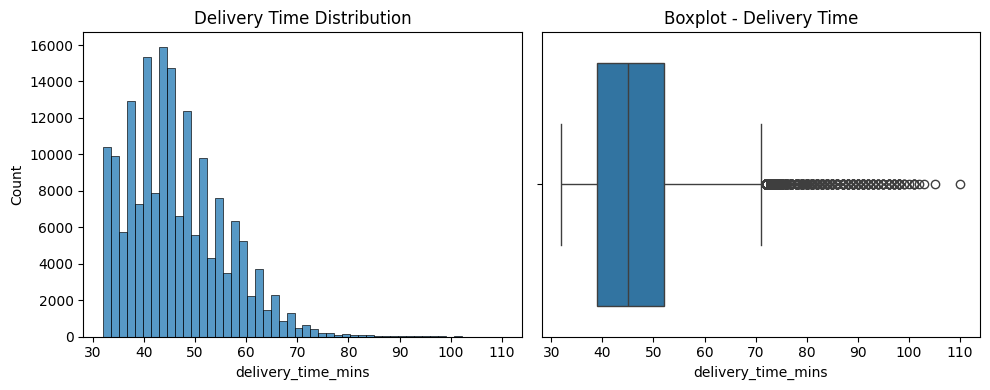

count    175777.000000
mean         46.203013
std           9.327424
min          32.000000
25%          39.000000
50%          45.000000
75%          52.000000
max         110.000000
Name: delivery_time_mins, dtype: float64


In [42]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['delivery_time_mins'], bins=50)
plt.title('Delivery Time Distribution')

plt.subplot(1,2,2)
sns.boxplot(x=df['delivery_time_mins'])
plt.title('Boxplot - Delivery Time')

plt.tight_layout()
plt.show()

print(df['delivery_time_mins'].describe())

In [ ]:

non_negative_cols = [
    'total_items', 'subtotal', 'num_distinct_items',
    'min_item_price', 'max_item_price',
    'total_onshift_dashers', 'total_busy_dashers',
    'total_outstanding_orders',
    'estimated_store_to_consumer_driving_duration',
    'price_range', 'avg_item_price', 'orders_per_partner'
]

print("Rows before dropping negatives:", len(df))

for col in non_negative_cols:
    df = df[df[col] >= 0]

print("Rows after dropping negatives:", len(df))

numeric_cols = non_negative_cols  

for col in numeric_cols:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)

print("\nAfter clipping:")
print(df[numeric_cols].describe().loc[['min', 'max']])
print("\nFinal shape:", df.shape)

Rows before dropping negatives: 175777
Rows after dropping negatives: 174998

After clipping:
     total_items  subtotal  num_distinct_items  min_item_price  \
min          1.0      0.00                 1.0             0.0   
max         12.0   9471.12                 8.0          2500.0   

     max_item_price  total_onshift_dashers  total_busy_dashers  \
min             0.0                    0.0                 0.0   
max          3100.0                  136.0               126.0   

     total_outstanding_orders  estimated_store_to_consumer_driving_duration  \
min                       0.0                                           0.0   
max                     213.0                                        1046.0   

     price_range  avg_item_price  orders_per_partner  
min          0.0             0.0            0.000000  
max       2200.0          3499.0            2.333333  

Final shape: (174998, 25)


In [44]:
numeric_cols = [
    'total_items', 'subtotal', 'num_distinct_items',
    'min_item_price', 'max_item_price',
    'total_onshift_dashers', 'total_busy_dashers',
    'total_outstanding_orders',
    'estimated_store_to_consumer_driving_duration',
    'price_range', 'avg_item_price', 'orders_per_partner'
]

print("Before clipping:")
print(df[numeric_cols].describe().loc[['min', 'max']])

for col in numeric_cols:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)

print("\nAfter clipping:")
print(df[numeric_cols].describe().loc[['min', 'max']])
print("\nShape after clipping:", df.shape)

Before clipping:
     total_items  subtotal  num_distinct_items  min_item_price  \
min          1.0      0.00                 1.0             0.0   
max         12.0   9471.12                 8.0          2500.0   

     max_item_price  total_onshift_dashers  total_busy_dashers  \
min             0.0                    0.0                 0.0   
max          3100.0                  136.0               126.0   

     total_outstanding_orders  estimated_store_to_consumer_driving_duration  \
min                       0.0                                           0.0   
max                     213.0                                        1046.0   

     price_range  avg_item_price  orders_per_partner  
min          0.0             0.0            0.000000  
max       2200.0          3499.0            2.333333  

After clipping:
     total_items   subtotal  num_distinct_items  min_item_price  \
min          1.0     0.0000                 1.0             0.0   
max         12.0  9471.0036    

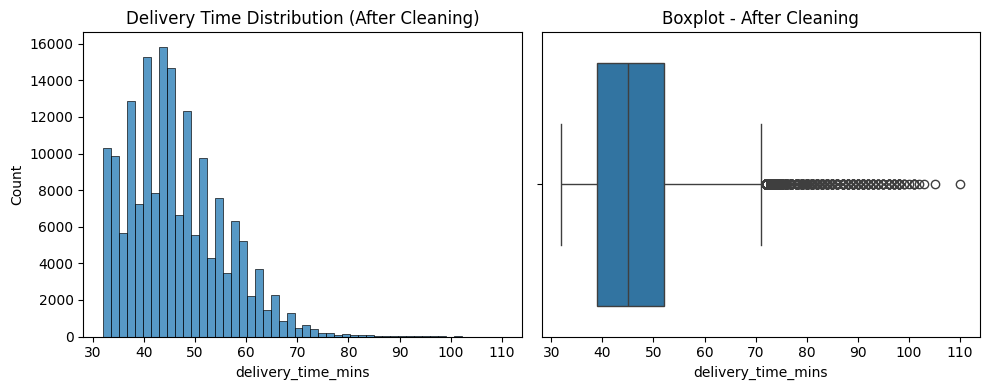

count    174998.000000
mean         46.210014
std           9.329575
min          32.000000
25%          39.000000
50%          45.000000
75%          52.000000
max         110.000000
Name: delivery_time_mins, dtype: float64


In [45]:

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['delivery_time_mins'], bins=50)
plt.title('Delivery Time Distribution (After Cleaning)')

plt.subplot(1,2,2)
sns.boxplot(x=df['delivery_time_mins'])
plt.title('Boxplot - After Cleaning')

plt.tight_layout()
plt.show()

print(df['delivery_time_mins'].describe())

In [46]:

df.to_csv('porter_processed.csv', index=False)
print("Saved! Final shape:", df.shape)
print("\nColumns saved:")
print(df.columns.tolist())

Saved! Final shape: (174998, 25)

Columns saved:
['market_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'estimated_store_to_consumer_driving_duration', 'delivery_time_mins', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_rush_hour', 'time_of_day', 'price_range', 'avg_item_price', 'is_large_order', 'busy_partner_ratio', 'available_partners', 'orders_per_partner', 'is_high_demand']
